      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  

Missing values:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 557.5045 - mae: 21.9952 - val_loss: 410.3379 - val_mae: 17.6342
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 483.8733 - mae: 20.3161 - val_loss: 338.0127 - val_mae: 15.3737
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 390.2277 - mae: 18.0073 - val_loss: 253.7830 - val_mae: 13.0583
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 273.0771 - mae: 14.6484 - val_loss: 173.8590 - val_mae: 10.3720
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 158.7382 - mae: 10.4736 - val_loss: 128.7262 - val_mae: 9.3492
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 88.2823 - mae: 7.4625 - val_loss: 119.8291 - val_mae: 9.4723
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 62.6630 - mae: 5.9939 - val_loss: 91.9324 - val_mae: 8.1810
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.4675 - mae: 4.9612 - val_loss: 60.4029 - val_mae: 6.5390
Epoch 9/100
12/12 ━━━━━

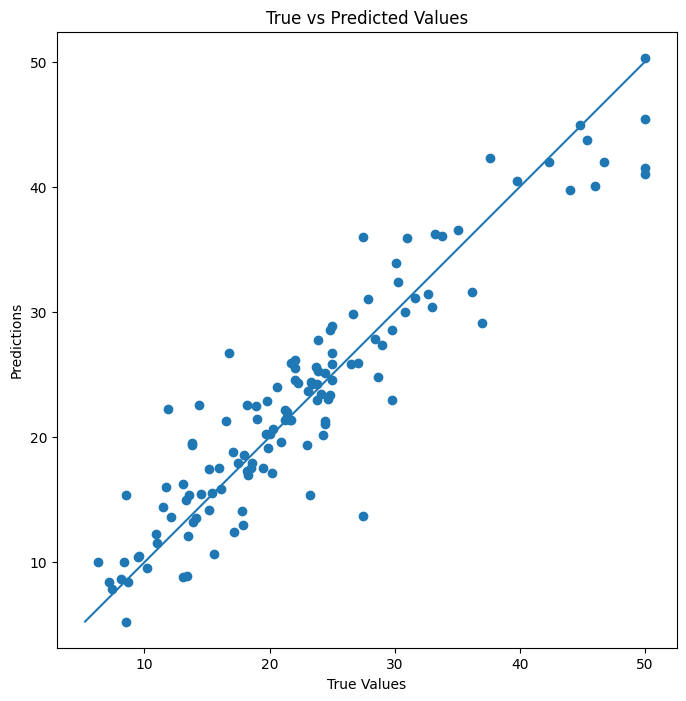

In [3]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv('boston_house_prices.csv')

print(df.head())
print("\nMissing values:\n", df.isnull().sum())

# ==============================
# FEATURES & TARGET
# ==============================
X = df.drop('PRICE', axis=1).values
y = df['PRICE'].values  # FIX: 1D instead of (n,1)

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=45
)

# ==============================
# NORMALIZATION
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# MODEL
# ==============================
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(13,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==============================
# TRAINING
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

# ==============================
# EVALUATION
# ==============================
y_pred = model.predict(X_test)

mse_nn, mae_nn = model.evaluate(X_test, y_test, verbose=0)
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("Mean squared error:", mse_nn)
print("Mean absolute error:", mae_nn)
print("Accuracy (R2 Score):", r2 * 100)
print("==============================")

# ==============================

plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred)

p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))

plt.plot([p1, p2], [p1, p2])

plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")

plt.axis('equal')
plt.show()